In [3]:
import pandas as pd
import glob
import os

path = 'archive' 
all_files = glob.glob(os.path.join(path, "*.csv"))

if not all_files:
    print("HATA: CSV dosyaları bulunamadı! Lütfen 'archive' klasörünün adını kontrol et.")
else:
    for filename in all_files:
        print("\n" + "="*60)
        print(f"DOSYA ADI: {os.path.basename(filename)}")
        
        # İlk 5 satırı ve sütun isimlerini oku [cite: 147, 228]
        df_preview = pd.read_csv(filename, nrows=5)
        
        print("\nSÜTUN İSİMLERİ:")
        print(df_preview.columns.tolist())
        
        print("\nİLK 5 SATIR (ÖNİZLEME):")
        print(df_preview)
        print("="*60)


DOSYA ADI: renewable_capacity_timeseries.csv

SÜTUN İSİMLERİ:
['day', 'CH_bioenergy_capacity', 'CH_solar_capacity', 'CH_wind_onshore_capacity', 'DE_bioenergy_capacity', 'DE_geothermal_capacity', 'DE_solar_capacity', 'DE_wind_capacity', 'DE_wind_offshore_capacity', 'DE_wind_onshore_capacity', 'DK_solar_capacity', 'DK_wind_capacity', 'DK_wind_offshore_capacity', 'DK_wind_onshore_capacity', 'FR_bioenergy_capacity', 'FR_geothermal_capacity', 'FR_hydro_capacity', 'FR_marine_capacity', 'FR_solar_capacity', 'FR_wind_onshore_capacity', 'GB-GBN_bioenergy_capacity', 'GB-GBN_hydro_capacity', 'GB-GBN_marine_capacity', 'GB-GBN_solar_capacity', 'GB-GBN_wind_capacity', 'GB-GBN_wind_offshore_capacity', 'GB-GBN_wind_onshore_capacity', 'GB-NIR_bioenergy_capacity', 'GB-NIR_solar_capacity', 'GB-NIR_wind_onshore_capacity', 'GB-UKM_bioenergy_capacity', 'GB-UKM_hydro_capacity', 'GB-UKM_marine_capacity', 'GB-UKM_solar_capacity', 'GB-UKM_wind_capacity', 'GB-UKM_wind_offshore_capacity', 'GB-UKM_wind_onshore_ca

In [6]:
import pandas as pd
import glob
import os
from sklearn.preprocessing import StandardScaler

# Dosya yolunu ayarla
path = os.path.join('archive', '*.csv')
all_files = glob.glob(path)

li = []

for filename in all_files:
    try:
        # on_bad_lines='skip': Bozuk satırları atlar
        # low_memory=False: Bellek hatalarını (buffer overflow) önlemeye yardımcı olur
        df_temp = pd.read_csv(filename, on_bad_lines='skip', low_memory=False)
        
        # Sütun isimlerindeki boşlukları temizleyelim
        df_temp.columns = df_temp.columns.str.strip()
        
        if 'day' in df_temp.columns:
            # Tarih formatını zorla (Hatalı tarihleri NaT yapar)
            df_temp['day'] = pd.to_datetime(df_temp['day'], errors='coerce')
            # Tarihi bozuk olan satırları at
            df_temp = df_temp.dropna(subset=['day'])
            df_temp.set_index('day', inplace=True)
            
            # Sadece kapasite içeren sayısal sütunları al [cite: 145]
            capacity_cols = [col for col in df_temp.columns if '_capacity' in col]
            
            # Veri tipini float'a zorla (Hatalı sayıları NaN yapar)
            for col in capacity_cols:
                df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')
            
            li.append(df_temp[capacity_cols])
            print(f"Başarıyla okundu: {os.path.basename(filename)}")
            
    except Exception as e:
        print(f"HATA: {os.path.basename(filename)} dosyası okunurken hata oluştu: {e}")

if not li:
    print("İşlenecek veri bulunamadı!")
else:
    # Tüm tabloları birleştir [cite: 149]
    df_combined = pd.concat(li, axis=1)

    # Rapor Bölüm 2 & 3.1: Eksik verileri doğrusal interpolasyon ile doldur [cite: 87, 136]
    df_cleaned = df_combined.interpolate(method='time').fillna(0)

    # PCA ve K-Means için ölçeklendirme [cite: 170]
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_cleaned)

    print("\n" + "="*30)
    print(f"Toplam sütun sayısı: {scaled_data.shape[1]}")
    print("Veri temizleme ve birleştirme tamam!")

Başarıyla okundu: renewable_capacity_timeseries.csv
HATA: renewable_power_plants_UK.csv dosyası okunurken hata oluştu: Error tokenizing data. C error: Buffer overflow caught - possible malformed input file.


Toplam sütun sayısı: 39
Veri temizleme ve birleştirme tamam!


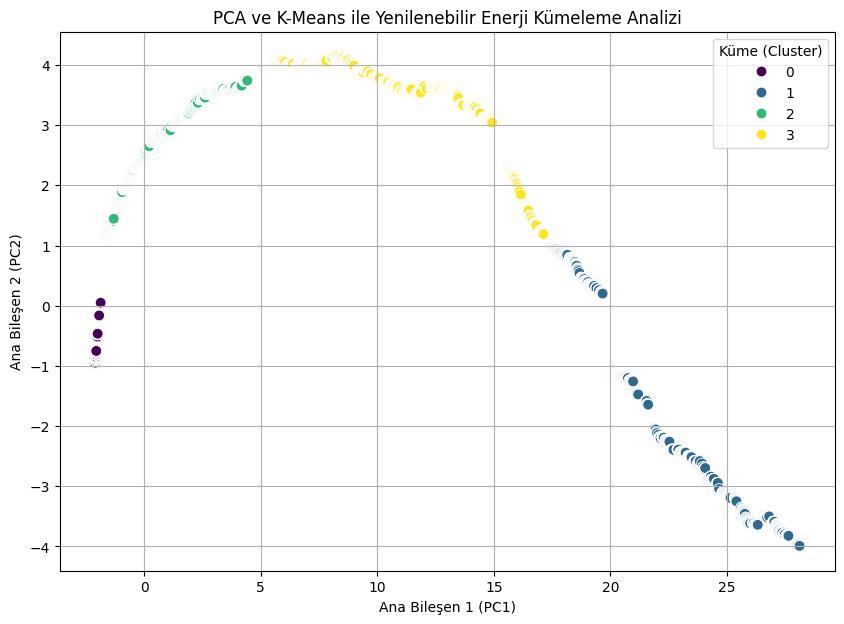


Küme Bazlı Ortalama Kapasiteler:
Cluster
0      24.167984
1    7513.054393
2     559.171274
3    3857.682737
dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. PCA Uygula (2 boyuta indirelim ki grafik çizebilelim)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data) # scaled_data bir önceki adımda hazırlandı

# 2. K-Means Uygula (Kaç küme yapacağımızı seçelim, örn: 4)
# Raporda bahsedilen 'clustering countries with similar energy policies' kısmı burası 
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# 3. Sonuçları Görselleştirme (Seaborn kullanarak)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=clusters, palette='viridis', s=60)
plt.title('PCA ve K-Means ile Yenilenebilir Enerji Kümeleme Analizi')
plt.xlabel('Ana Bileşen 1 (PC1)')
plt.ylabel('Ana Bileşen 2 (PC2)')
plt.legend(title='Küme (Cluster)')
plt.grid(True)
plt.show()

# Her kümenin özelliklerine bakalım (Hangi grupta ne yoğunlukta?)
# df_cleaned: temizlenmiş ana veri çerçeven
df_cleaned['Cluster'] = clusters
print("\nKüme Bazlı Ortalama Kapasiteler:")
print(df_cleaned.groupby('Cluster').mean().mean(axis=1)) # Basitleştirilmiş özet

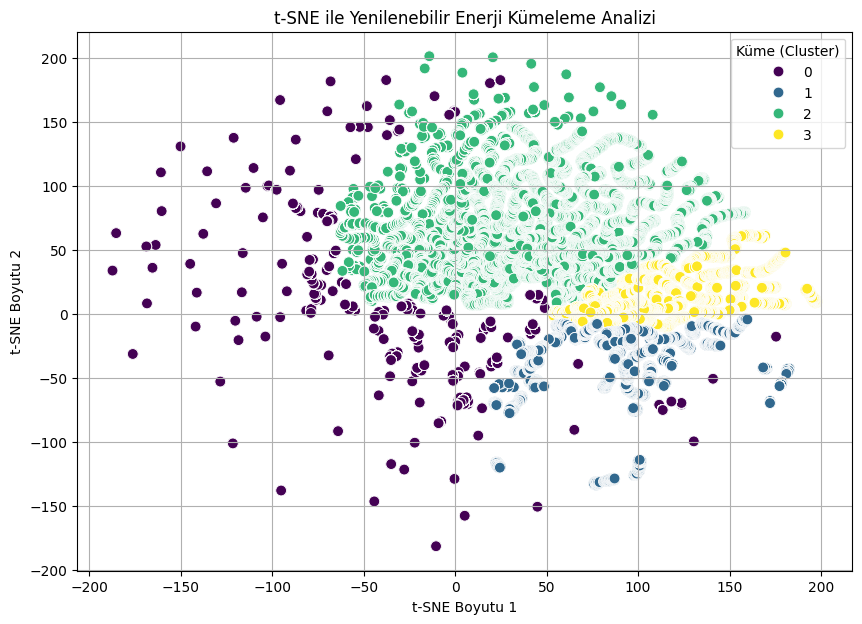

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. t-SNE Uygula
# Perplexity: Komşuluk ilişkilerini belirler, 30-50 arası genelde idealdir.
# learning_rate: Gradyan inişi hızı, 'auto' genelde iyi sonuç verir.
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
tsne_data = tsne.fit_transform(scaled_data) # Temizlenmiş ve ölçeklenmiş verini kullanıyoruz

# 2. Görselleştirme
plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_data[:, 0], y=tsne_data[:, 1], hue=clusters, palette='viridis', s=60)

plt.title('t-SNE ile Yenilenebilir Enerji Kümeleme Analizi')
plt.xlabel('t-SNE Boyutu 1')
plt.ylabel('t-SNE Boyutu 2')
plt.legend(title='Küme (Cluster)')
plt.grid(True)
plt.show()